In [40]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, add
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from keras.layers import MultiHeadAttention, LayerNormalization
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm_notebook
from collections import Counter
import re
from nltk.translate.bleu_score import corpus_bleu
from tensorflow.keras.callbacks import ReduceLROnPlateau
import zipfile
import csv
import gc
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
import plotly.graph_objects as go
from keras.applications import efficientnet

In [3]:
images_directory = './Data/IC30K/flickr30k_images/flickr30k_images/'
captions_path = 'flickr30k_images/results.csv'
#captions_path = './Data/IC30K/flickr30k_images/results.csv'
zip_path = './Data/IC30K.zip'

def load_captions(zip_path, csv_filename):
    captions = []
    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(csv_filename) as f:
            reader = csv.DictReader(
                (line.decode('utf-8') for line in f), delimiter='|'
            )
            reader.fieldnames = [name.strip() for name in reader.fieldnames]
            for row in reader:
                img = row.get('image_name')
                caption = row.get('comment')
                if caption:
                    captions.append(f"{img},{caption.strip().lower()}")
    return captions

def tokenize_captions(captions):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(captions)
    return tokenizer

#captions = load_captions(captions_path)
captions = load_captions(zip_path, captions_path)
captions[:15:3]

['1000092795.jpg,two young guys with shaggy hair look at their hands while hanging out in the yard .',
 '1000092795.jpg,a man in a blue shirt standing in a garden .',
 '10002456.jpg,workers look down from up above on a piece of equipment .',
 '10002456.jpg,three men on a large rig .',
 '1000268201.jpg,a little girl climbing the stairs to her playhouse .']

In [5]:
def clean_text(text):
    # Lowercase
    lowercase = tf.strings.lower(text)
    # Characters to strip (punctuation + digits)
    strip_chars = "!\"#$%&'()*+,-./:;=?@[\]^_`{|}~1234567890"
    # Regex replace
    cleaned = tf.strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")
    # Convert back to Python string
    return cleaned.numpy().decode("utf-8").strip()

cleaned_captions = [clean_text(caption.split(',')[1]) for caption in captions]
cleaned_captions[:15:2]

['two young guys with shaggy hair look at their hands while hanging out in the yard',
 'two men in green shirts are standing in a yard',
 'two friends enjoy time spent together',
 'workers look down from up above on a piece of equipment',
 'four men on top of a tall structure',
 'a child in a pink dress is climbing up a set of stairs in an entry way',
 'a little girl climbing the stairs to her playhouse',
 'a girl going into a wooden building']

In [45]:
#def clean_text(text):
#    text = re.sub(r'[^\w\s]', '', text)
#    text = re.sub(r'\d+', '', text)
#    text = re.sub(r'\s+', ' ', text).strip()
#    return text
    
#cleaned_captions = [clean_text(caption.split(',')[1]) for caption in captions]
#cleaned_captions[:15:2]

['two young guys with shaggy hair look at their hands while hanging out in the yard',
 'two men in green shirts are standing in a yard',
 'two friends enjoy time spent together',
 'workers look down from up above on a piece of equipment',
 'four men on top of a tall structure',
 'a child in a pink dress is climbing up a set of stairs in an entry way',
 'a little girl climbing the stairs to her playhouse',
 'a girl going into a wooden building']

In [6]:
# Define min and max caption length
MIN_LEN = 4
MAX_LEN = 24   # same as SEQ_LENGTH in Transformer

filtered_captions = []
filtered_ids = []

for i, caption in enumerate(cleaned_captions):
    tokens = caption.split()
    if MIN_LEN <= len(tokens) <= MAX_LEN:
        filtered_captions.append(caption)
        item = captions[i].split(',')[0] + '\t' + 'start ' + caption + ' end\n'
        filtered_ids.append(item)

# Replace old lists with filtered ones
cleaned_captions = filtered_captions
captions_IDs = filtered_ids

captions_IDs[:20:3], len(captions_IDs)

(['1000092795.jpg\tstart two young guys with shaggy hair look at their hands while hanging out in the yard end\n',
  '1000092795.jpg\tstart two friends enjoy time spent together end\n',
  '10002456.jpg\tstart two men working on a machine wearing hard hats end\n',
  '1000268201.jpg\tstart a child in a pink dress is climbing up a set of stairs in an entry way end\n',
  '1000268201.jpg\tstart a little girl climbing into a wooden playhouse end\n',
  '1000344755.jpg\tstart a man in a blue shirt is standing on a ladder cleaning a window end\n',
  '1000344755.jpg\tstart a man on a ladder cleans a window end\n'],
 153044)

In [48]:
#captions_IDs = []
#for i in range(len(cleaned_captions)):
#    item = captions[i].split(',')[0]+'\t'+'start '+cleaned_captions[i]+' end\n'
#    captions_IDs.append(item)

#captions_IDs[:20:3], len(captions_IDs)

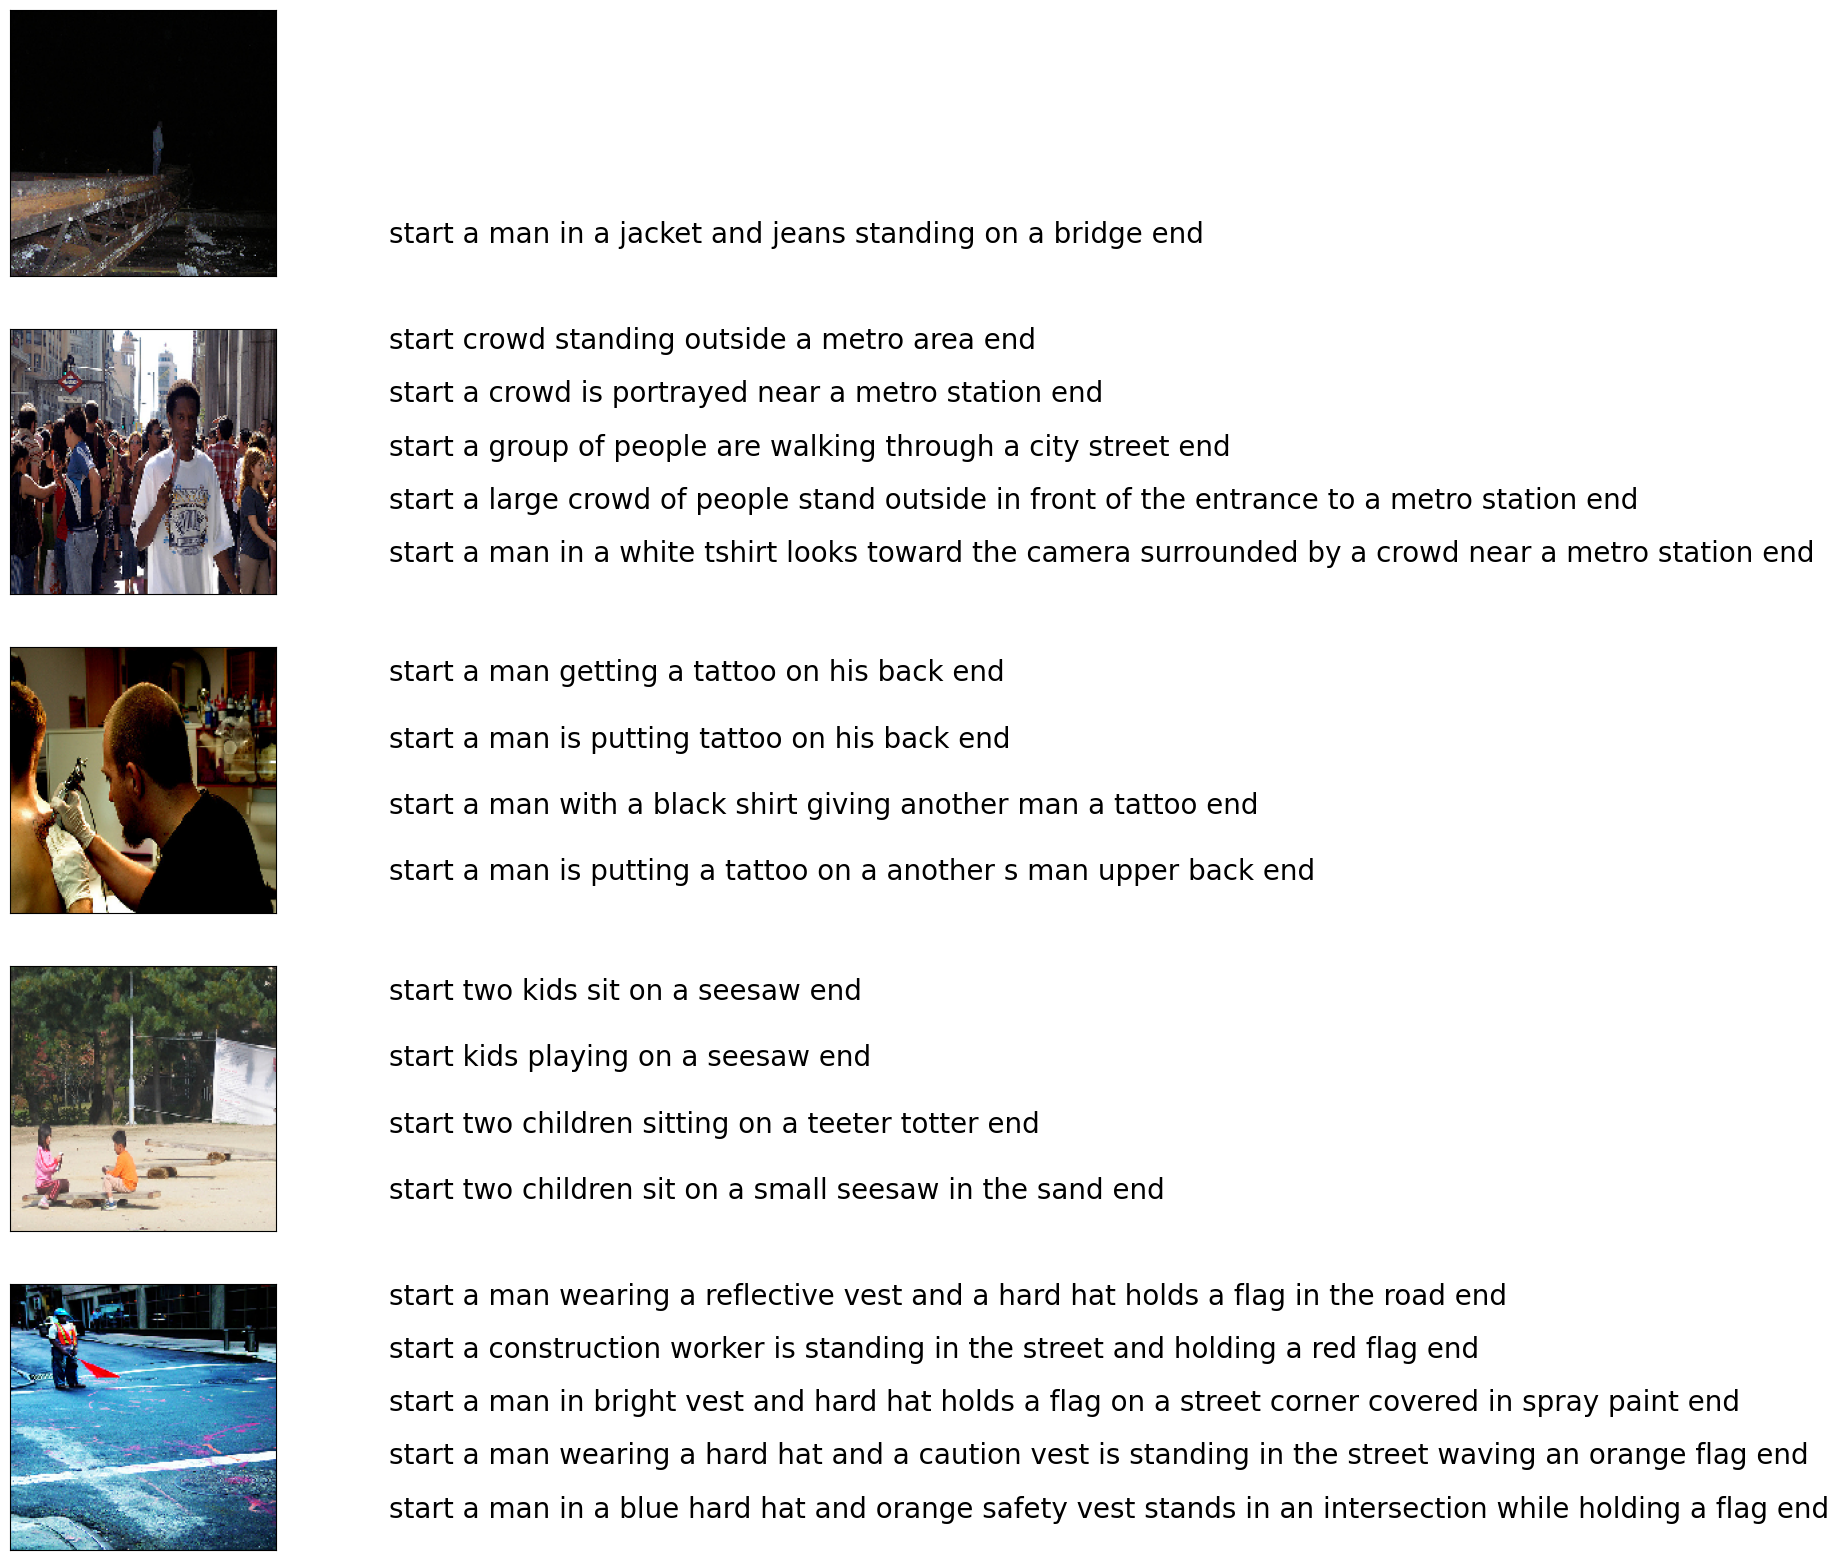

In [7]:
def visualaization(data, num_of_images):
    captions_dictionary = {}
    for item in data[100:100+(num_of_images)*5]:
        image_id, caption = item.split('\t')
        if image_id not in captions_dictionary:
            captions_dictionary[image_id] = []
        captions_dictionary[image_id].append(caption)
    #else:
    #    list_captions = [x for x in captions_dictionary.items()]

    count = 1
    fig = plt.figure(figsize=(10,20))
    for filename in list(captions_dictionary.keys())[:num_of_images]:
        captions = captions_dictionary[filename]
        image_load = load_img(images_directory+filename, target_size=(199,199,3))

        ax = fig.add_subplot(num_of_images,2,count,xticks=[],yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images,2,count)
        plt.axis('off')
        ax.plot()
        ax.set_xlim(0,1)
        ax.set_ylim(0,len(captions))
        for i, caption in enumerate(captions):
            ax.text(0,i,caption,fontsize=20)
        count += 1
    plt.show()

visualaization(captions_IDs, 5)

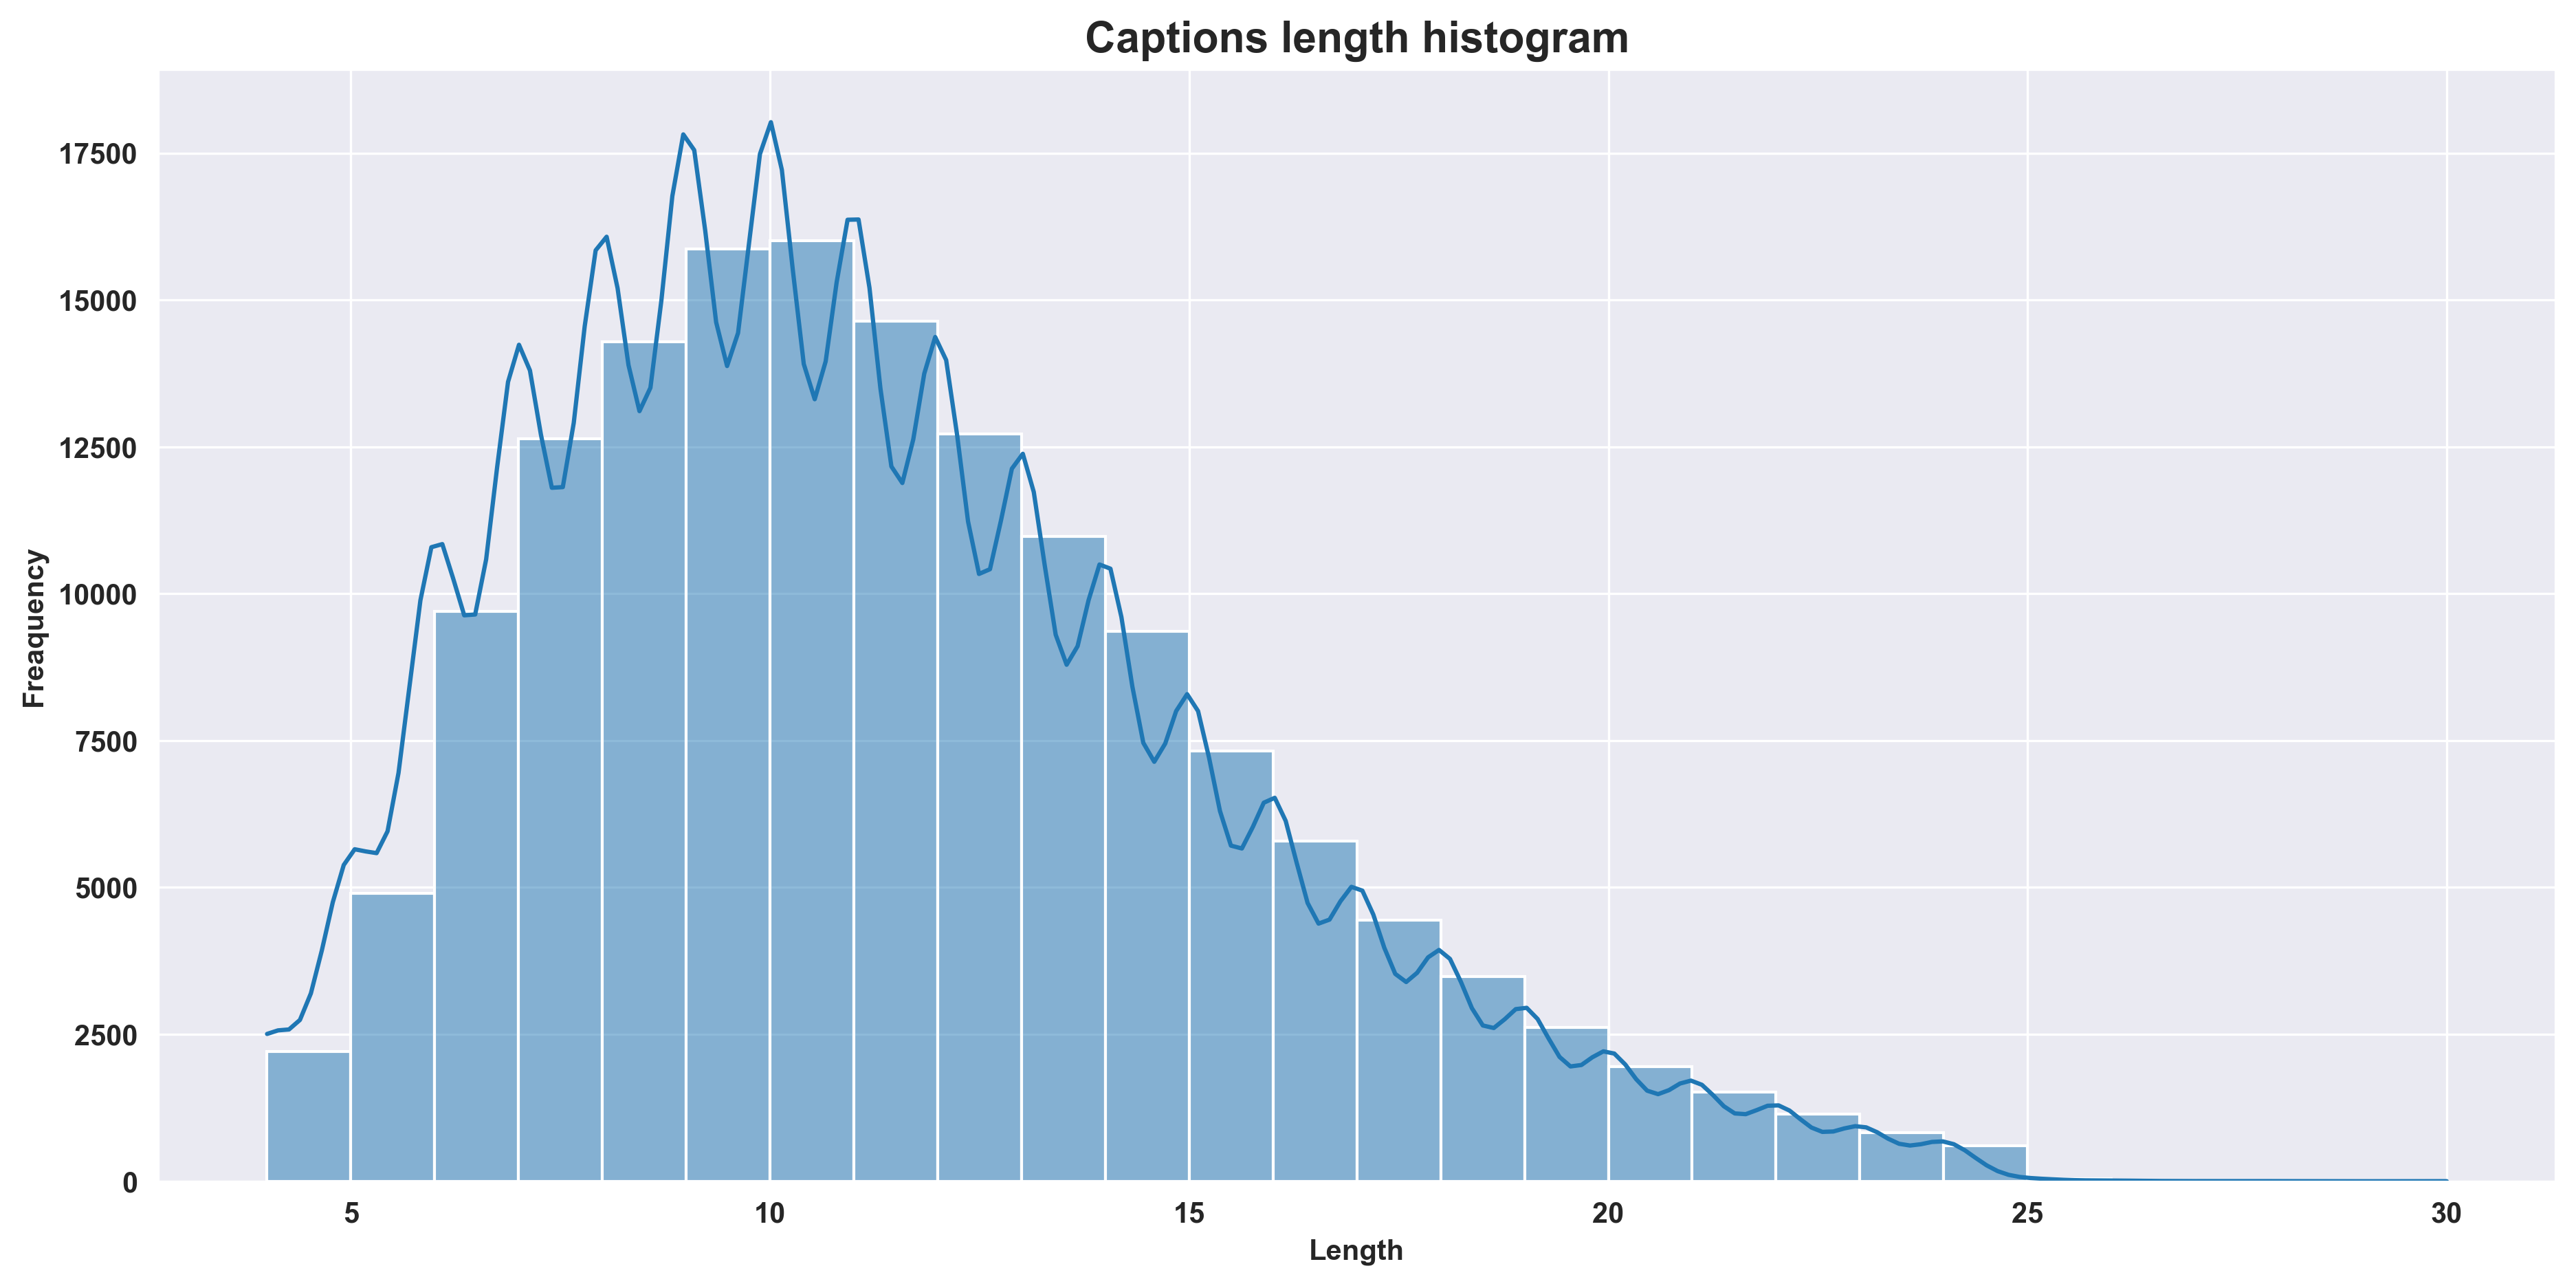

In [8]:
def captions_length(data):
    plt.figure(figsize=(15, 7), dpi=300)
    sns.set_style('darkgrid')
    sns.histplot(x=[len(x.split(' ')) for x in data], kde=True, binwidth=1)
    plt.title('Captions length histogram', fontsize=15, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Length', fontweight='bold')
    plt.ylabel('Freaquency', fontweight='bold')
    plt.show()

captions_length(cleaned_captions)

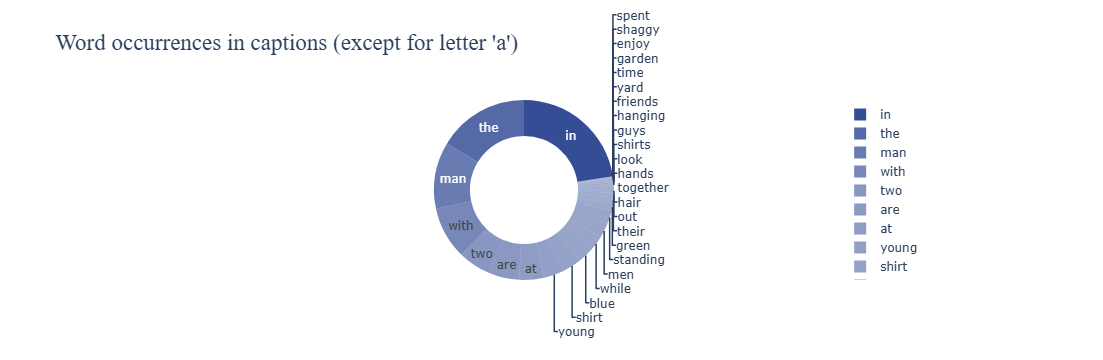

In [19]:
def word_occurrences(data):
    # Combining all sentences into a single string
    all_text = ' '.join(data)
    all_text = all_text.replace('a ', '')
    all_text = all_text.replace('start ', '')
    all_text = all_text.replace('end ', '')
    # Splitting the text into words and count occurrences
    word_counts = Counter(all_text.split())

    words = list(word_counts.keys())[:30]
    values = list(word_counts.values())[:30]

    # Normalize values to be between 0 and 1
    normalized_values = np.array(values) / np.max(values)
    colors = np.array(['rgba(30, 58, 138, {})'.format(0.4 + 0.5 * (value)) for value in normalized_values])

    fig = go.Figure(data=[go.Pie(labels=words, values=values, hole=.6, marker=dict(colors=colors), textinfo='label')])

    fig.update_layout(title_text='Word occurrences in captions (except for letter \'a\')', title_font=dict(size=23, family='Balto'))

    fig.show()
    
word_occurrences(cleaned_captions)

In [21]:
tokenizer = tokenize_captions(cleaned_captions)
vocab_size = len(tokenizer.word_index) + 1
vocab_size

18417

In [23]:
#all_image_ids = os.listdir(images_directory)

all_image_ids = [
    f for f in os.listdir(images_directory)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

train_image_ids, val_image_ids = train_test_split(all_image_ids, test_size=0.15, random_state=42)
val_image_ids, test_image_ids = train_test_split(val_image_ids, test_size=0.1, random_state=42)

train_captions, val_captions, test_captions = [], [], []
for caption in captions_IDs:
    image_id, _ = caption.split('\t')

    if image_id in train_image_ids:
        train_captions.append(caption)

    elif image_id in val_image_ids:
        val_captions.append(caption)

    elif image_id in test_image_ids:
        test_captions.append(caption)

    else:
        print('Unknown image ID !')

train_captions[0], val_captions[0], test_captions[0], len(train_captions)/5, len(val_captions)/5, len(test_captions)/5

('1000092795.jpg\tstart two young guys with shaggy hair look at their hands while hanging out in the yard end\n',
 '1000919630.jpg\tstart a man sits in a chair while holding a large stuffed animal of a lion end\n',
 '1001465944.jpg\tstart an asian man wearing a black suit stands near a darkhaired woman and a brownhaired woman end\n',
 26022.4,
 4128.4,
 458.0)

In [28]:
# Define augmentation pipeline
image_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.3)
])

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)

    # Apply augmentation
    img = image_augmentation(img)

    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img

def extract_image_features(model, image_path):
    img = preprocess_image(image_path)
    features = model.predict(img, verbose=0)
    return features

inception_v3_model = InceptionV3(weights = 'imagenet', input_shape=(299, 299, 3))
inception_v3_model.layers.pop()
inception_v3_model = Model(inputs=inception_v3_model.inputs, outputs=inception_v3_model.layers[-2].output)

In [30]:
BATCH_SIZE = 10000
train_image_features, val_image_features, test_image_features = {}, {}, {}  # A Dictionary to store image features with their corresponding IDs

def process_batch(batch_ids, model, batch_index,train_image_features, val_image_features, test_image_features):
    count = 0
    
    for image_id in batch_ids:
        image_path = os.path.join(images_directory, image_id)
        image_features = extract_image_features(model, image_path)
        count+=1
        if image_id in train_image_ids:
            train_image_features[image_id] = image_features.flatten()  # Flattening the features
            #traincount+=1
            pbar.update(1)

        elif image_id in val_image_ids:
            val_image_features[image_id] = image_features.flatten()  # Flattening the features
            #valcount+=1
            pbar.update(1)

        elif image_id in test_image_ids:
            test_image_features[image_id] = image_features.flatten()  # Flattening the features
            #testcount+=1
            pbar.update(1)

        else:
            print('Unknown image ID !')
        print("Count: ",str(count))
    
    # Save batch to disk
    #np.savez(f'features_batch_{batch_index}.npz', **features_dict)
    
    # Clear memory
    #del features_dict
    gc.collect()
    print(f"Batch {batch_index} saved with {len(batch_ids)} images.")
    return train_image_features, val_image_features, test_image_features

pbar = tqdm_notebook(total=len(all_image_ids), position=0, leave=True, colour='green')

# Split all_image_ids into chunks of 10k
for i in range(0, len(all_image_ids), BATCH_SIZE):
    batch_ids = all_image_ids[i:i+BATCH_SIZE]
    train_image_features, val_image_features, test_image_features = process_batch(batch_ids, inception_v3_model, i//BATCH_SIZE, train_image_features, val_image_features, test_image_features)
    print(len(train_image_features))
    print(len(val_image_features))
    print(len(test_image_features))
    print("BATCH: ",str(i+BATCH_SIZE))

pbar.close()
print('Done')

  0%|          | 0/31783 [00:00<?, ?it/s]

Count:  1
Count:  2
Count:  3
Count:  4
Count:  5
Count:  6
Count:  7
Count:  8
Count:  9
Count:  10
Count:  11
Count:  12
Count:  13
Count:  14
Count:  15
Count:  16
Count:  17
Count:  18
Count:  19
Count:  20
Count:  21
Count:  22
Count:  23
Count:  24
Count:  25
Count:  26
Count:  27
Count:  28
Count:  29
Count:  30
Count:  31
Count:  32
Count:  33
Count:  34
Count:  35
Count:  36
Count:  37
Count:  38
Count:  39
Count:  40
Count:  41
Count:  42
Count:  43
Count:  44
Count:  45
Count:  46
Count:  47
Count:  48
Count:  49
Count:  50
Count:  51
Count:  52
Count:  53
Count:  54
Count:  55
Count:  56
Count:  57
Count:  58
Count:  59
Count:  60
Count:  61
Count:  62
Count:  63
Count:  64
Count:  65
Count:  66
Count:  67
Count:  68
Count:  69
Count:  70
Count:  71
Count:  72
Count:  73
Count:  74
Count:  75
Count:  76
Count:  77
Count:  78
Count:  79
Count:  80
Count:  81
Count:  82
Count:  83
Count:  84
Count:  85
Count:  86
Count:  87
Count:  88
Count:  89
Count:  90
Count:  91
Count:  

In [32]:
def data_generator(captions, image_features, tokenizer, max_caption_length, batch_size):
    num_samples = len(captions)
    image_ids = list(image_features.keys())
    while True:
        np.random.shuffle(image_ids)  # Shuffle image_ids for each epoch
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            X_images, X_captions, y = [], [], []
            for caption in captions[start_idx:end_idx]:
                image_id, caption_text = caption.split('\t')
                caption_text = caption_text.rstrip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0] # Tokenizing the caption
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i] # X_caption, Y
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X_images.append(image_features[image_id])
                    X_captions.append(in_seq)
                    y.append(out_seq)

            yield [np.array(X_images), np.array(X_captions)], np.array(y)


max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 1

cnn_output_dim = inception_v3_model.output_shape[1] # 2048

batch_size_train = 128 #270
batch_size_val = 64 #150

train_data_generator = data_generator(train_captions, train_image_features, tokenizer, max_caption_length, batch_size_train)
val_data_generator = data_generator(val_captions, val_image_features, tokenizer, max_caption_length, batch_size_val)

In [34]:
# Unzip once (you can skip if already extracted)
zip_path = "./Data/glove.2024.wikigiga.300d.zip"
extract_dir = "./Data/"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

embedding_path = "./Data/wiki_giga_2024_300_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05_combined.txt"

In [35]:
def load_embeddings(embedding_path, tokenizer, embedding_dim=300):
    vocab_size = len(tokenizer.word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    # Only keep words in tokenizer
    with open(embedding_path, encoding="utf8") as f:
        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            if word in tokenizer.word_index:
                idx = tokenizer.word_index[word]
                if idx < vocab_size:
                    embedding_matrix[idx] = np.asarray(values[1:], dtype="float32")
    return embedding_matrix

In [36]:
embedding_matrix = load_embeddings(embedding_path, tokenizer, embedding_dim=300)

In [44]:
def build_model(vocab_size, max_caption_length, cnn_output_dim, embedding_matrix=None, embedding_dim=300):
    # Image feature branch
    base_model = efficientnet.EfficientNetB0(include_top=False, weights="imagenet", input_shape=(299,299,3))
    base_model.trainable = False
    input_image = Input(shape=(cnn_output_dim,), name='Features_Input')
    fe1 = BatchNormalization()(input_image)
    fe2 = Dense(256, activation='relu')(fe1)
    fe2 = Dropout(0.4)(fe2)
    fe3 = BatchNormalization()(fe2)

    # Caption sequence branch
    input_caption = Input(shape=(max_caption_length,), name='Sequence_Input')
    if embedding_matrix is not None:
        # Use pretrained Dolma/GloVe embeddings
        se1 = Embedding(vocab_size,
                        embedding_dim,
                        weights=[embedding_matrix],
                        input_length=max_caption_length,
                        trainable=True,#False
                        mask_zero=True)(input_caption)
    else:
        # Fallback: train embeddings from scratch
        se1 = Embedding(vocab_size, 256, mask_zero=True)(input_caption)

    # Stacked LSTMs for richer sequence modeling
    se2 = LSTM(256, return_sequences=True)(se1)
    attn_out = MultiHeadAttention(num_heads=4, key_dim=256)(se2, se2)
    se3 = LayerNormalization()(se2 + attn_out)
    se3 = LSTM(256)(se3)
    se3 = Dropout(0.4)(se3)

    # Decoder
    decoder1 = add([fe3, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    decoder2 = Dropout(0.4)(decoder2)
    outputs = Dense(vocab_size, activation='softmax', name='Output_Layer')(decoder2)

    model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Captioning')
    return model

caption_model = build_model(vocab_size, max_caption_length, cnn_output_dim, embedding_matrix=embedding_matrix, embedding_dim=300)
#caption_model = build_model(vocab_size, max_caption_length, cnn_output_dim, embedding_matrix=None)

class WarmupLearningRate(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, target_lr=1e-4, warmup_steps=1000):
        super().__init__()
        self.target_lr = target_lr
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        # Linear warmup
        warmup_lr = self.target_lr * (step / warmup_steps)
        return tf.cond(step < warmup_steps,
                       lambda: warmup_lr,
                       lambda: self.target_lr)

lr_schedule = WarmupLearningRate(target_lr=1e-4, warmup_steps=2000)
optimizer = Adam(learning_rate=lr_schedule, clipnorm=1.0)
#optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)
caption_model.compile(loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05), optimizer=optimizer)#'categorical_crossentropy'

caption_model.summary()

Model: "Image_Captioning"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Sequence_Input (InputLayer)    [(None, 25)]         0           []                               
                                                                                                  
 embedding_1 (Embedding)        (None, 25, 300)      5525100     ['Sequence_Input[0][0]']         
                                                                                                  
 lstm_2 (LSTM)                  (None, 25, 256)      570368      ['embedding_1[0][0]']            
                                                                                                  
 Features_Input (InputLayer)    [(None, 2048)]       0           []                               
                                                                                   

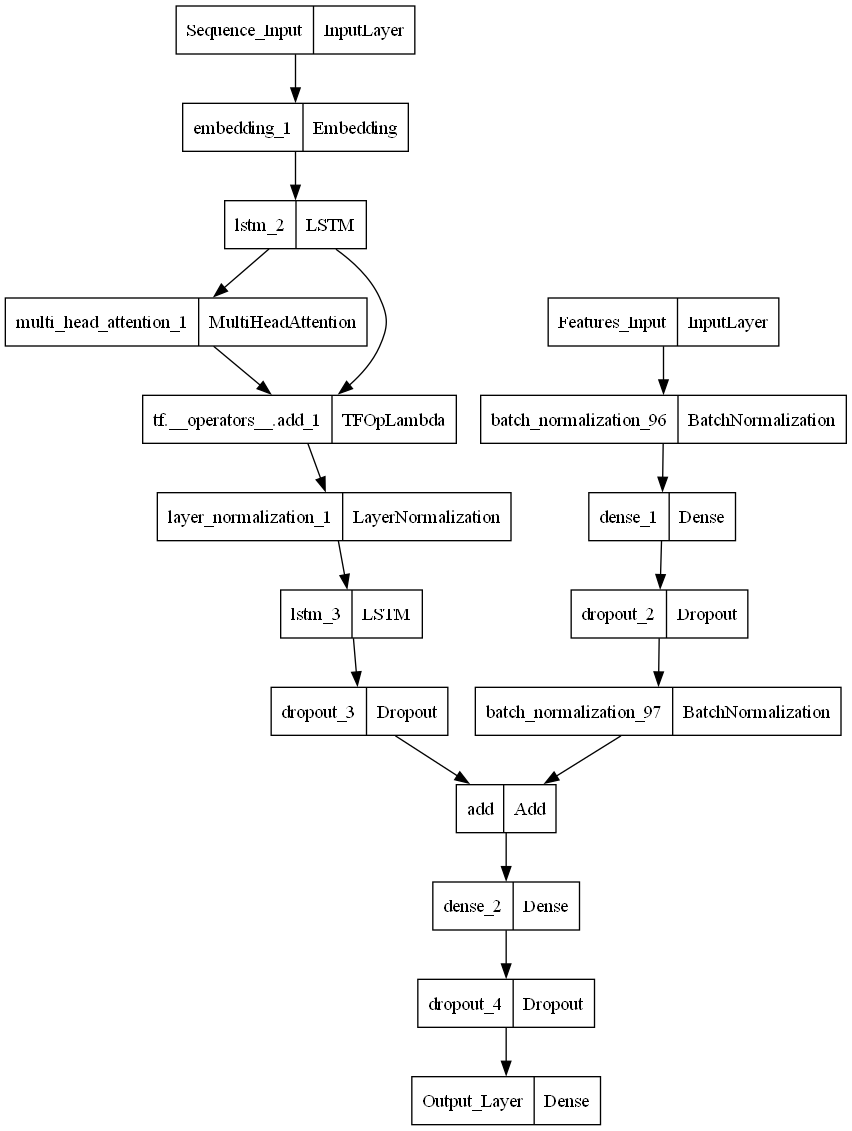

In [46]:
plot_model(caption_model)

In [48]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#def lr_scheduler(epoch, lr):
#    new_lr = lr * tf.math.exp(-0.05)
#    return max(new_lr, 1e-5)

#lr_schedule = LearningRateScheduler(lr_scheduler)
#lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = caption_model.fit(train_data_generator, steps_per_epoch=len(train_captions) // batch_size_train,
                        validation_data=val_data_generator, validation_steps=len(val_captions) // batch_size_val,
                        epochs=100, callbacks=[early_stopping])

Epoch 1/100
1016/1016 [==============================] - 890s 864ms/step - loss: 7.3879 - val_loss: 5.7996
Epoch 2/100
1016/1016 [==============================] - 804s 792ms/step - loss: 5.2662 - val_loss: 4.6522
Epoch 3/100
1016/1016 [==============================] - 775s 763ms/step - loss: 4.5848 - val_loss: 4.3045
Epoch 4/100
1016/1016 [==============================] - 771s 759ms/step - loss: 4.3527 - val_loss: 4.1398
Epoch 5/100
1016/1016 [==============================] - 771s 759ms/step - loss: 4.2157 - val_loss: 4.0395
Epoch 6/100
1016/1016 [==============================] - 765s 753ms/step - loss: 4.1180 - val_loss: 3.9606
Epoch 7/100
1016/1016 [==============================] - 767s 755ms/step - loss: 4.0438 - val_loss: 3.9029
Epoch 8/100
1016/1016 [==============================] - 771s 759ms/step - loss: 3.9840 - val_loss: 3.8579
Epoch 9/100
1016/1016 [==============================] - 766s 754ms/step - loss: 3.9345 - val_loss: 3.8191
Epoch 10/100
1016/1016 [=============

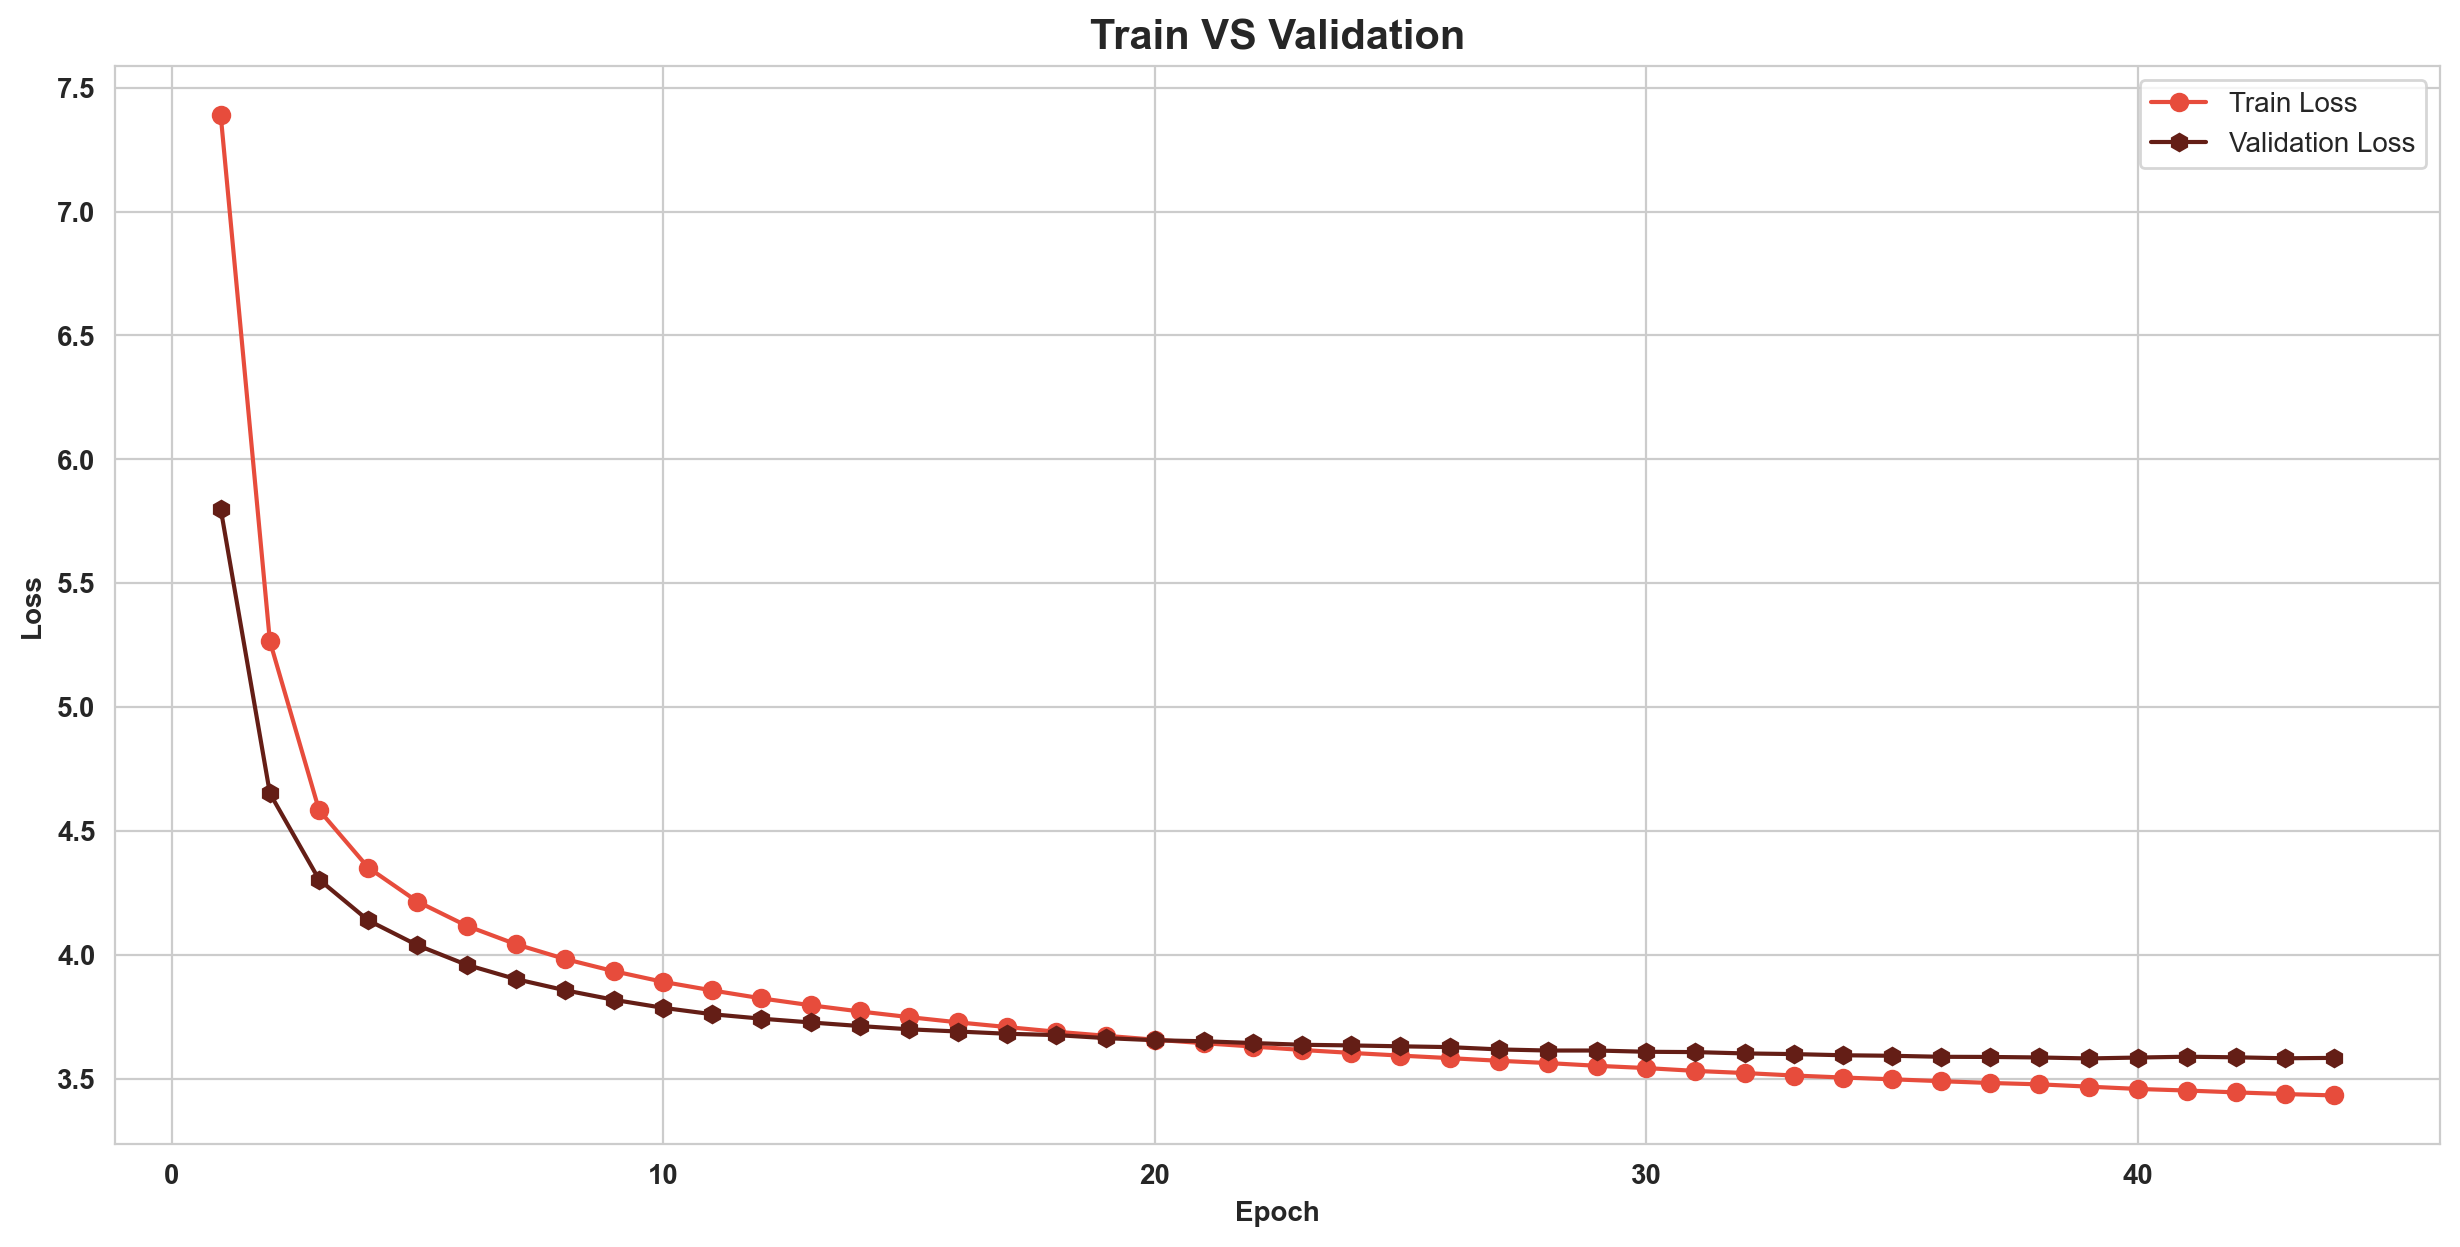

In [50]:
plt.figure(figsize=(15, 7), dpi=200)
sns.set_style('whitegrid')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['loss'], color='#E74C3C', marker='o')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['val_loss'], color='#641E16', marker='h')
plt.title('Train VS Validation', fontsize=15, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend(['Train Loss', 'Validation Loss'], loc='best')
plt.show()

In [52]:
def greedy_generator(image_features):
    in_text = 'start '
    for _ in range(max_caption_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_caption_length).reshape((1,max_caption_length))
        prediction = caption_model.predict([image_features.reshape(1,cnn_output_dim), sequence], verbose=0)
        idx = np.argmax(prediction)
        word = tokenizer.index_word[idx]
        in_text += ' ' + word
        if word == 'end':
            break

    in_text = in_text.replace('start ', '')
    in_text = in_text.replace(' end', '')

    return in_text

In [54]:
def beam_search_generator(image_features, K_beams = 3, log = False):
    start = [tokenizer.word_index['start']]
    start_word = [[start, 0.0]]
    for _ in range(max_caption_length):
        temp = []
        for s in start_word:
            sequence  = pad_sequences([s[0]], maxlen=max_caption_length).reshape((1,max_caption_length))
            preds = caption_model.predict([image_features.reshape(1,cnn_output_dim), sequence], verbose=0)
            word_preds = np.argsort(preds[0])[-K_beams:]
            for w in word_preds:
                next_cap, prob = s[0][:], s[1]
                next_cap.append(w)
                if log:
                    prob += np.log(preds[0][w]) # assign a probability to each K words
                else:
                    prob += preds[0][w]
                temp.append([next_cap, prob])
                
        start_word = temp
        start_word = sorted(start_word, reverse=False, key=lambda l: l[1])
        start_word = start_word[-K_beams:]

    start_word = start_word[-1][0]
    captions_ = [tokenizer.index_word[i] for i in start_word]
    final_caption = []
    for i in captions_:
        if i != 'end':
            final_caption.append(i)
        else:
            break
        
    final_caption = ' '.join(final_caption[1:])
    return final_caption

In [68]:
def BLEU_score(actual, greedy, beam_search):
    score_greedy_1 = corpus_bleu(actual, greedy, weights=(1, 0, 0, 0)) 
    #score_greedy_1 = corpus_bleu(actual, greedy, weights=(0.3, 0.3, 0.3, 0))
    score_greedy_2 = corpus_bleu(actual, greedy, weights=(0.5, 0.5, 0, 0)) 
    #score_greedy_2 = corpus_bleu(actual, greedy, weights=(0.25, 0.25, 0.25, 0.25))
    score_BS_1 = corpus_bleu(actual, beam_search, weights=(1, 0, 0, 0)) 
    #score_BS_1 = corpus_bleu(actual, beam_search, weights=(0.3, 0.3, 0.3, 0))
    score_BS_2 = corpus_bleu(actual, beam_search, weights=(0.5, 0.5, 0, 0)) 
    #score_BS_2 = corpus_bleu(actual, beam_search, weights=(0.25, 0.25, 0.25, 0.25))
    
    return [
        (f'BLEU-2 Greedy: {round(score_BS_2, 5)}'),
        (f'BLEU-1 Greedy: {round(score_BS_1, 5)}'),
        (f'Greedy: {greedy[0]}'),
        (f'BLEU-2 Beam Search: {round(score_greedy_2, 5)}'),
        (f'BLEU-1 Beam Search: {round(score_greedy_1, 5)}'),
        (f'Beam Search:  {beam_search[0]}')
    ]

In [58]:
generated_captions = {}

pbar = tqdm_notebook(total=len(test_image_features), position=0, leave=True, colour='green')
for image_id in test_image_features:
    cap = greedy_generator(test_image_features[image_id])
    generated_captions[image_id] = cap
    pbar.update(1)

pbar.close()

  0%|          | 0/477 [00:00<?, ?it/s]

In [59]:
test_actual_captions = {}
for line in test_captions:
    filename, caption = line.split("\t", 1)
    caption = caption.strip()
    #if caption.startswith("start "):
    #    caption = caption[len("start "):]    # cut off "start "
    #if caption.endswith(" end"):
    #    caption = caption[:-len(" end")]     # cut off " end"

    test_actual_captions[filename] = caption

#print(test_actual_captions)

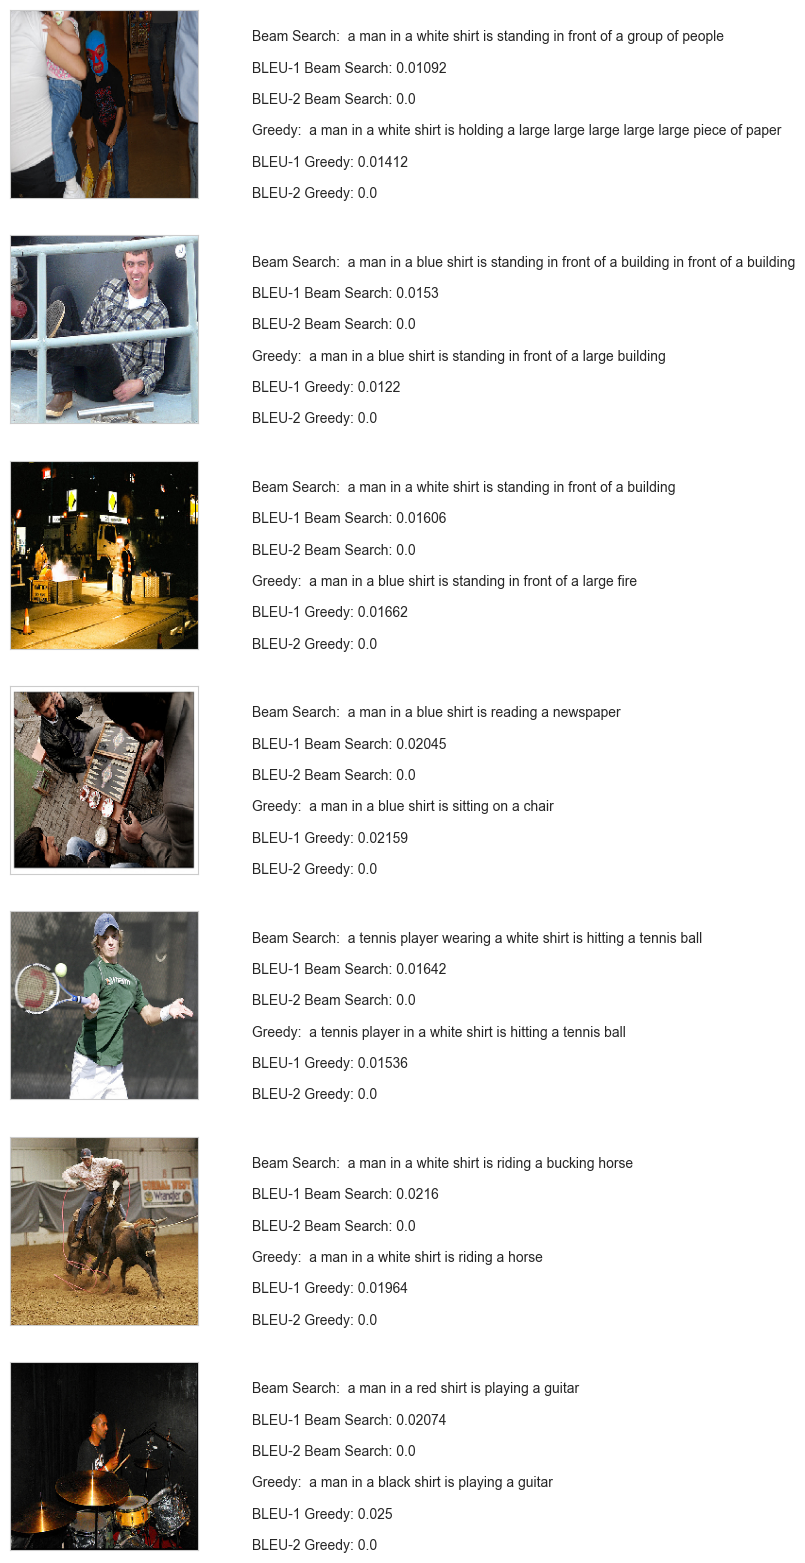

In [70]:
def visualization(data, greedy_caps, beamS_generator, evaluator, num_of_images):
    keys = list(data.keys()) 
    images = [np.random.choice(keys) for i in range(num_of_images)] # Randomly selected images
    count = 1
    fig = plt.figure(figsize=(6,20))
    for filename in images:
        actual_cap = data[filename]
        actual_cap = [x.replace("start ", "") for x in actual_cap]
        actual_cap = [x.replace(" end", "") for x in actual_cap]

        greedy_cap = greedy_caps[filename]
        beamS_cap = beamS_generator(test_image_features[filename])

        caps_with_score = evaluator(actual_cap, [greedy_cap]*(len(actual_cap)), [beamS_cap]*(len(actual_cap)))

        image_load = load_img(images_directory+filename, target_size=(199,199,3))
        ax = fig.add_subplot(num_of_images,2,count,xticks=[],yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images,2,count)
        plt.axis('off')
        ax.plot()
        ax.set_xlim(0,1)
        ax.set_ylim(0,len(caps_with_score))
        for i, text in enumerate(caps_with_score):
            ax.text(0,i,text,fontsize=10)
        count += 1
    plt.show()

visualization(test_actual_captions, generated_captions, beam_search_generator, BLEU_score, 7)